# Data Analysis and Model Training for the Risk Factors for Cardiovascular Heart Disease Dataset

# Experimental Protocol – Cardiovascular Disease Prediction

## Purpose of this Notebook

This notebook constitutes the experimental backbone for one dataset in a
multi-dataset comparative study on binary medical classification.

The objectives are:
1. To establish strong classical machine learning baselines.
2. To evaluate whether deep learning models provide measurable benefits
   on tabular medical data.
3. To assess model robustness, uncertainty, and statistical significance.
4. To analyze model interpretability using post-hoc explanation techniques.

The results generated here are intended to be directly reusable in a
peer-reviewed scientific publication.

## Experimental Roadmap

1. Dataset characterization and exploratory analysis  
2. Preprocessing and robustness handling  
3. Classical ML benchmarking with cross-validation  
4. Statistical significance testing  
5. Model interpretability analysis  
6. Deep learning comparison  


The *Risk Factors for Cardiovascular Heart Disease* dataset contains detailed information on 70,000 adult individuals, including age, gender, height, weight, and various risk factors described below that may influence whether a person develops cardiovascular disease. Based on these features, multiple machine learning models will be trained, and their predictive performance and metrics will be compared.

First, let us install the basic libraries required for this analysis:

Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import random
import itertools
import time

from scipy.stats.mstats import winsorize
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

### Reproducibility

In [5]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

Next, we load the data into a pandas DataFrame `df` and inspect the first records.

Load Data

In [6]:
path = r'heart_data.csv'
df = pd.read_csv(path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (70000, 14)


,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 1. Basic Dataset Information

At first glance, all features appear to be numerical. Let us examine the basic dataset metadata.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        70000 non-null  int64  
 1   id           70000 non-null  int64  
 2   age          70000 non-null  int64  
 3   gender       70000 non-null  int64  
 4   height       70000 non-null  int64  
 5   weight       70000 non-null  float64
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gluc         70000 non-null  int64  
 10  smoke        70000 non-null  int64  
 11  alco         70000 non-null  int64  
 12  active       70000 non-null  int64  
 13  cardio       70000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 7.5 MB


The dataset contains 70,000 rows, where each row represents one individual, and 14 columns, each corresponding to a feature.

There are no missing values, and all features are numerical. The weight column is of floating-point type, while the remaining features are integers.

Below is a description of each column:

- `index` — unique identifier for each record
- `id` — unique identifier for each record
- `age` — age in days
- `gender` — biological sex (male / female)
- `height` — height in centimeters
- `weight` — weight in kilograms
- `ap_hi` — systolic blood pressure
- `ap_lo` — diastolic blood pressure
- `cholesterol` — total cholesterol level in mg/dL, scaled from 0–5 (each unit ≈ 20 mg/dL)
- `gluc` — glucose level in mmol/L, scaled from 0–16 (each unit ≈ 1 mmol/L)
- `smoke` — smoking status (0 = no, 1 = yes)
- `alco` — alcohol consumption (0 = no, 1 = yes)
- `active` — physical activity status (0 = no, 1 = yes)
- `cardio` — presence of cardiovascular disease (0 = no, 1 = yes)

The final column represents the target variable that the models will predict.

### Class Distribution

In [8]:
class_counts = df['cardio'].value_counts()
class_ratios = class_counts / len(df)

display(pd.DataFrame({
    "Count": class_counts,
    "Ratio": class_ratios
}))

,Count,Ratio
cardio,,
0,35021,0.5003
1,34979,0.4997


The dataset is approximately class-balanced, with nearly equal proportions
of positive and negative cases. This allows performance differences between
models to be interpreted without confounding effects caused by class
imbalance, while stratified cross-validation is used to ensure consistency across cross-validation folds.

Class proportions in this dataset should not be interpreted as reflecting
real-world disease prevalence.

## 2. Removal of Redundant Columns

Some columns contain unique identifiers that provide no predictive value. Therefore, the `index` and `id` columns are removed:

In [9]:
df = df.drop(['index', 'id'], axis=1)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 3. Feature Statistics

We examine descriptive statistics for all features:

In [10]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


The reported statistics include:

- count — number of non-missing values
- mean — arithmetic mean
- std — standard deviation
- min — minimum value
- 25% — first quartile
- 50% — median
- 75% — third quartile
- max — maximum value

We convert age to years:

In [11]:
df['age'] = (df['age'] / 365).apply(int)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


## 4. Missing Values

We verify the presence of missing values:

In [12]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


No missing values are present in the dataset.

## 5. Duplicate Records

We check for duplicate rows:

In [13]:
df.duplicated().value_counts()

,count
False,66792
True,3208


The dataset contains 3,208 duplicate rows and 66,792 unique rows. Duplicates are removed while retaining the first occurrence:

In [14]:
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (66792, 12)


After removing redundant columns and duplicates, the dataset contains 66,792 rows and 12 features.

## 6. Outliers

We first analyze and then handle the outliers.

Two helper functions are defined:

- A function to compute outlier thresholds and summarize extreme values
- A function to visualize distributions using boxplots

In [15]:
def analyze_outliers(column, low=0, high=0, total=0):
    Q1 = df[column].quantile(.25)
    Q3 = df[column].quantile(.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_outliers_low = df[df[column] < lower_limit]
    df_outliers_high = df[df[column] > upper_limit]
    df_outliers_total = pd.concat([df_outliers_low, df_outliers_high])

    low_outliers_count = len(df_outliers_low)
    high_outliers_count = len(df_outliers_high)
    total_outliers_count = len(df_outliers_total)

    summary = f'''
lower quartile: {Q1}
upper quartile: {Q3}
interquartile range: {IQR}
lower limit: {lower_limit}
upper limit: {upper_limit}
number of outliers below the minimum: {low_outliers_count}
number of outliers above the maximum: {high_outliers_count}
total number of outliers: {total_outliers_count}
'''

    print(summary)

    if low > 0:
        print(f'Outliers below the minimum (number of records: {low}):\n')
        print(df_outliers_low.sort_values(by=column).head(low))

    if high > 0:
        print(f'Outliers above the maximum (number of records: {high}):\n')
        print(df_outliers_high.sort_values(by=column).head(high))

    if total > 0:
        print(f'Total outliers (number of records: {total}):\n')
        print(df_outliers_total.sort_values(by=column).head(total))

In [16]:
def show_outliers(column):
    plt.figure(figsize=(10, 1))
    sns.boxplot(data=df, x=df[column], orient="h")
    plt.grid()

The outlier analysis indicates:

**`age`**

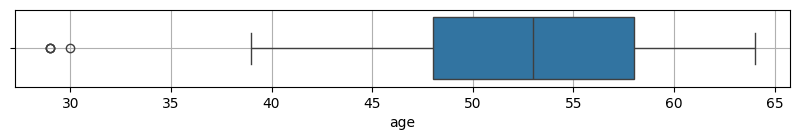

In [17]:
show_outliers('age')

Several low-end outliers exist.

**`gender`**

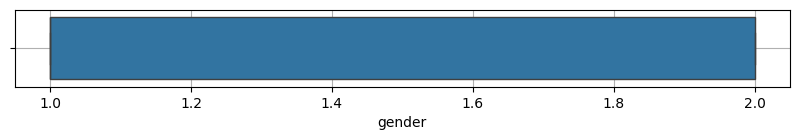

In [18]:
show_outliers('gender')

No outliers are present.

**`height`**

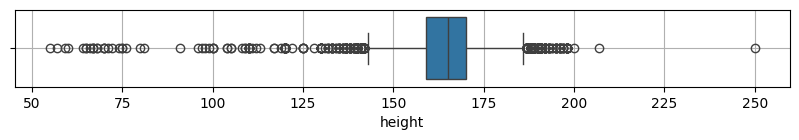

In [19]:
show_outliers('height')

Several extreme values occur below and above plausible human heights:

In [20]:
analyze_outliers('height', low=5, high=5, total=0)


lower quartile: 159.0
upper quartile: 170.0
interquartile range: 11.0
lower limit: 142.5
upper limit: 186.5
number of outliers below the minimum: 250
number of outliers above the maximum: 269
total number of outliers: 519

Outliers below the minimum (number of records: 5):

       age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
22723   64       1      55    81.0    130     90            1     1      0   
66643   51       1      57    61.0    130     90            1     1      0   
64115   50       1      59    57.6    125     67            1     1      0   
29157   52       1      60    69.0    110     70            1     1      0   
27603   57       1      64    61.0    130     70            1     1      0   

       alco  active  cardio  
22723     0       1       1  
66643     0       1       1  
64115     0       0       0  
29157     0       0       0  
27603     0       1       0  
Outliers above the maximum (number of records: 5):

       age  gender  hei

**`weight`**

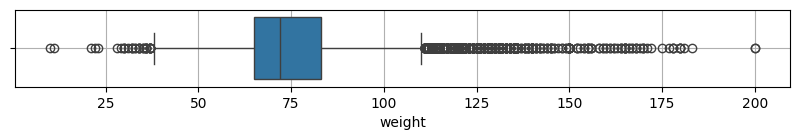

In [21]:
show_outliers('weight')

Many high-end outliers exist:

In [22]:
analyze_outliers('weight', low=5, high=5, total=0)


lower quartile: 65.0
upper quartile: 83.0
interquartile range: 18.0
lower limit: 38.0
upper limit: 110.0
number of outliers below the minimum: 35
number of outliers above the maximum: 1247
total number of outliers: 1282

Outliers below the minimum (number of records: 5):

       age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
57858   51       2     165    10.0    180   1100            2     2      0   
33817   59       2     178    11.0    130     90            1     1      0   
60188   59       1     162    21.0    120     80            2     1      0   
29488   55       2     177    22.0    120     80            1     1      1   
26806   63       1     157    23.0    110     80            1     1      0   

       alco  active  cardio  
57858     0       1       1  
33817     0       1       1  
60188     0       1       1  
29488     1       1       0  
26806     0       1       0  
Outliers above the maximum (number of records: 5):

       age  gender  heigh

**`ap_hi`**

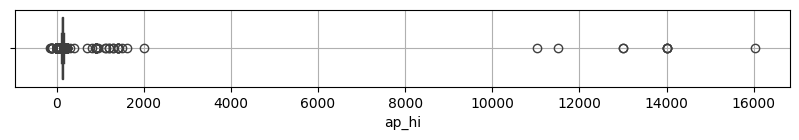

In [23]:
show_outliers('ap_hi')

Many high-end outliers exist:

In [24]:
analyze_outliers('ap_hi', low=5, high=5, total=0)


lower quartile: 120.0
upper quartile: 140.0
interquartile range: 20.0
lower limit: 90.0
upper limit: 170.0
number of outliers below the minimum: 319
number of outliers above the maximum: 1114
total number of outliers: 1433

Outliers below the minimum (number of records: 5):

       age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
35040   63       2     168    59.0   -150     80            1     1      0   
23988   50       1     162    74.0   -140     90            1     1      0   
25240   40       2     168    50.0   -120     80            2     1      0   
46627   64       2     160    59.0   -120     80            1     1      0   
16021   60       2     161    90.0   -115     70            1     1      0   

       alco  active  cardio  
35040     0       1       1  
23988     0       1       1  
25240     0       0       1  
46627     0       0       0  
16021     0       1       0  
Outliers above the maximum (number of records: 5):

       age  gender  he

**`ap_lo`**

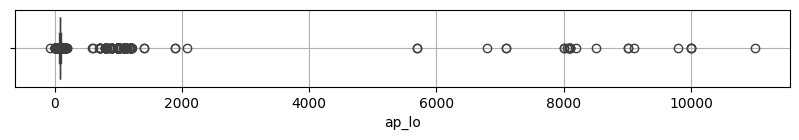

In [25]:
show_outliers('ap_lo')

Many high-end outliers exist:

In [26]:
analyze_outliers('ap_lo', low=5, high=5, total=0)


lower quartile: 80.0
upper quartile: 90.0
interquartile range: 10.0
lower limit: 65.0
upper limit: 105.0
number of outliers below the minimum: 2917
number of outliers above the maximum: 1700
total number of outliers: 4617

Outliers below the minimum (number of records: 5):

       age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
60106   61       1     167    74.0     15    -70            1     1      0   
68663   49       1     156    41.0    906      0            1     1      0   
65303   64       2     176    99.0    120      0            1     3      0   
63787   40       2     161    61.0    117      0            1     1      0   
56950   41       1     164    70.0    120      0            1     1      0   

       alco  active  cardio  
60106     0       1       1  
68663     0       1       0  
65303     0       1       1  
63787     0       1       0  
56950     0       1       0  
Outliers above the maximum (number of records: 5):

       age  gender  hei

For the following features, all values fall within valid ranges:

**`cholesterol`**

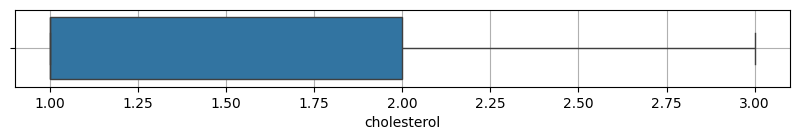

In [27]:
show_outliers('cholesterol')

**`gluc`**

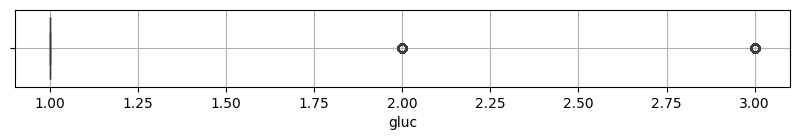

In [28]:
show_outliers('gluc')

**`smoke`**

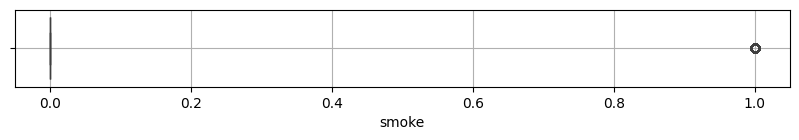

In [29]:
show_outliers('smoke')

**`alco`**

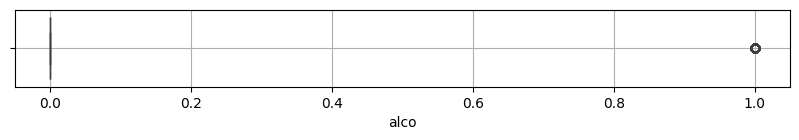

In [30]:
show_outliers('alco')

**`active`**

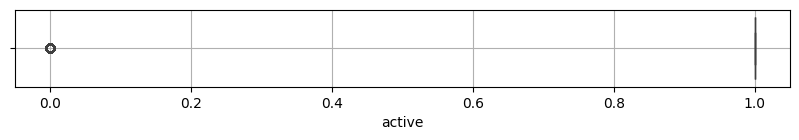

In [31]:
show_outliers('active')

### Winsorization

All data is retained as far as outliers are concerned, but we reduce the influence of extreme values by means of winsorization:

In [32]:
WIN_LIMITS = (0.01, 0.01)

def winsorize_column(col, limits=WIN_LIMITS):
    # Applies winsorization to a pandas Series (column).
    # limits: A tuple (lower_limit, upper_limit) defining the percentiles for winsorization.
    return winsorize(col, limits=limits)

# Apply winsorization to specified numerical columns to reduce the impact of extreme outliers
for col in ["height", "weight", "ap_hi", "ap_lo"]:
    df[col] = winsorize_column(df[col])

Winsorization identifies values below a certain lower percentile and above a certain upper percentile. It then replaces all values below the lower percentile with the value at that lower percentile, and all values above the upper percentile with the value at that upper percentile.

It's convenient because it retains all data points, preventing data loss that would occur if extreme outliers were simply removed. It reduces the undue influence of highly anomalous values (like the physiologically implausible blood pressure or height/weight readings observed during outlier analysis) on statistical analyses and machine learning models, without discarding potentially valuable information.

## 7. Data Cleaning and Preprocessing

### Feature / target split

In [33]:
# Separate features (X) from the target variable (y)
X = df.drop(columns="cardio") # Features DataFrame
y = df["cardio"] # Target Series (cardiovascular disease presence)

## 8. Pipelines and Hyperparameters

In [34]:
# Define a dictionary to store machine learning pipelines and their corresponding hyperparameter grids.
# Each entry consists of a pipeline object and a dictionary of hyperparameters for RandomizedSearchCV.
pipelines = {
    "Logistic Regression": (
        # Pipeline for Logistic Regression: first scales data, then applies Logistic Regression.
        Pipeline([
            ("scaler", StandardScaler()), # Standardize features by removing the mean and scaling to unit variance
            ("model", LogisticRegression(
                max_iter=2000, # Maximum number of iterations for the solver to converge
                class_weight="balanced", # Adjust weights inversely proportional to class frequencies
                random_state=SEED # Seed for reproducibility
            ))
        ]),
        # Hyperparameter grid for Logistic Regression: tuning the regularization strength (C)
        {"model__C": np.logspace(-3, 3, 20)} # C is the inverse of regularization strength
    ),

    "KNN": (
        # Pipeline for K-Nearest Neighbors: scales data, then applies KNN.
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()) # K-Nearest Neighbors classifier
        ]),
        # Hyperparameter grid for KNN: tuning number of neighbors and weight function
        {
            "model__n_neighbors": [3, 5, 7, 9, 11], # Number of neighbors to use
            "model__weights": ["uniform", "distance"] # Weight function used in prediction
        }
    ),

    "Decision Tree": (
        # Pipeline for Decision Tree: no scaling needed as tree-based models are not sensitive to scale.
        Pipeline([
            ("model", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=SEED
            ))
        ]),
        # Hyperparameter grid for Decision Tree: tuning tree depth and minimum samples for a split
        {
            "model__max_depth": [None, 5, 10, 20], # Maximum depth of the tree
            "model__min_samples_split": [2, 5, 10] # Minimum number of samples required to split an internal node
        }
    ),

    "Random Forest": (
        # Pipeline for Random Forest: no scaling needed.
        Pipeline([
            ("model", RandomForestClassifier(
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1 # Use all available CPU cores
            ))
        ]),
        # Hyperparameter grid for Random Forest: tuning number of estimators and tree depth
        {
            "model__n_estimators": [200, 400], # Number of trees in the forest
            "model__max_depth": [None, 10, 20] # Maximum depth of individual trees
        }
    ),

    "Gradient Boosting": (
        # Pipeline for Gradient Boosting: no scaling needed.
        Pipeline([
            ("model", GradientBoostingClassifier(random_state=42)) # Gradient Boosting classifier
        ]),
        # Hyperparameter grid for Gradient Boosting: tuning number of estimators, learning rate, and tree depth
        {
            "model__n_estimators": [100, 200, 400], # Number of boosting stages
            "model__learning_rate": [0.01, 0.05, 0.1], # Step size shrinkage to prevent overfitting
            "model__max_depth": [2, 3, 4] # Maximum depth of the individual regression estimators
        }
    ),

    "Naive Bayes": (
        # Pipeline for Gaussian Naive Bayes: only the model, as it doesn't have complex hyperparameters.
        Pipeline([("model", GaussianNB())]),
        {} # No hyperparameters to tune for Gaussian Naive Bayes in this setup
    )
}

## 9. Nested CV Evaluation

In [35]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # 5-fold stratified outer cross-validation

results = {name: [] for name in pipelines} # Dictionary to store performance metrics for each model per fold
probabilities = {name: [] for name in pipelines} # Dictionary to store predicted probabilities for each model across all folds
true_labels = [] # List to store true labels across all folds

print("Starting Classical ML Nested CV Evaluation...")
# Iterate through each fold of the outer cross-validation
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Fold {fold}")

    # Split data into training and test sets for the current fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    true_labels.extend(y_test.values) # Collect true labels for later statistical testing

    # Iterate through each defined machine learning pipeline
    for name, (pipe, params) in pipelines.items():
        start_time = time.time() # Start time measurement
        # If hyperparameters are defined, perform Randomized Search Cross-Validation (inner loop)
        if params:
            search = RandomizedSearchCV(
                pipe, # The pipeline to optimize
                params, # The hyperparameter distribution to sample from
                n_iter=20, # Number of parameter settings that are sampled
                scoring="roc_auc", # Metric to optimize for (keeping original)
                cv=3, # 3-fold cross-validation for the inner loop
                n_jobs=-1, # Use all available CPU cores
                random_state=SEED # Seed for reproducibility
            )
            search.fit(X_train, y_train) # Fit the randomized search on the training data
            model = search.best_estimator_ # Select the best model found by RandomizedSearchCV
        else:
            # If no hyperparameters, fit the pipeline directly
            model = pipe.fit(X_train, y_train)

        end_time = time.time() # End time measurement
        train_time = end_time - start_time # Calculate training time

        # Predict probabilities on the test set
        y_prob = model.predict_proba(X_test)[:, 1] # Probability of the positive class
        y_pred = (y_prob >= 0.5).astype(int) # Convert probabilities to binary predictions (threshold 0.5)

        # Store evaluation metrics and training time for the current fold
        metrics_dict = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob),
            "Average Precision": average_precision_score(y_test, y_prob),
            "Train Time": train_time
        }
        results[name].append(metrics_dict)

        # Store predicted probabilities for later statistical testing (Wilcoxon test)
        probabilities[name].extend(y_prob)
print("Classical ML Nested CV Evaluation Complete.")

Starting Classical ML Nested CV Evaluation...
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Classical ML Nested CV Evaluation Complete.


## 10. Aggregated Results

In [36]:
summary = {} # Dictionary to hold mean results for each model

# Calculate the mean of performance metrics across all folds for each model
for name, fold_results in results.items():
    df_tmp = pd.DataFrame(fold_results) # Convert fold results to a DataFrame
    summary[name] = df_tmp.mean() # Calculate mean for each metric

results_df = pd.DataFrame(summary).T # Convert the summary dictionary to a DataFrame, transpose for better readability
results_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Average Precision,Train Time
Logistic Regression,0.723245,0.757481,0.675782,0.714288,0.788233,0.778183,3.601365
KNN,0.710744,0.725117,0.700553,0.712612,0.766641,0.745126,176.517845
Decision Tree,0.729279,0.766967,0.677448,0.719156,0.791157,0.772653,4.825809
Random Forest,0.732139,0.770658,0.678794,0.721798,0.800154,0.790958,204.968959
Gradient Boosting,0.732588,0.754498,0.708040,0.730526,0.801159,0.791594,341.435232
Naive Bayes,0.665679,0.784629,0.478227,0.594232,0.768526,0.747174,0.018914


## 11. SHAP (trained on full data)

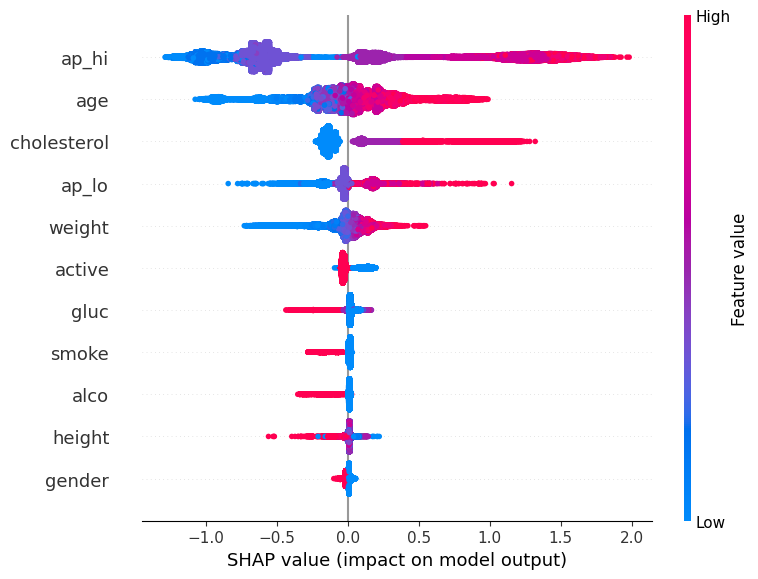

In [37]:
best_pipe, best_params = pipelines["Gradient Boosting"] # Retrieve the pipeline and parameters for the best performing model (Gradient Boosting)

# Train the best model on the entire dataset (X, y) for SHAP analysis.
# .named_steps["model"] extracts the actual model object from the pipeline.
best_model = best_pipe.fit(X, y).named_steps["model"]

# Initialize a TreeExplainer for tree-based models like Gradient Boosting
explainer = shap.TreeExplainer(best_model)
# Calculate SHAP values for the entire feature set X
shap_values = explainer.shap_values(X)

# Generate a summary plot of SHAP values. This plot shows feature importance
# and the impact of each feature on the model's output.
shap.summary_plot(shap_values, X)

## 12. Deep Learning Model: Multilayer Perceptron (PyTorch)

In addition to traditional machine learning models, a deep learning approach was implemented using PyTorch. The objective was to evaluate whether a neural network can outperform classical classifiers on the cardiovascular disease prediction task.

A **Multilayer Perceptron (MLP)** architecture was selected due to its suitability for tabular biomedical data.

In [38]:
def set_seed(seed=42):
    # Set seed for reproducibility across numpy and torch
    np.random.seed(seed)
    torch.manual_seed(seed)
    # Set CUDA seed for GPU operations if available
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior for CUDA (can impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [39]:
class MLP(nn.Module):
    # Defines a Multilayer Perceptron (MLP) for binary classification.
    # It includes fully connected layers, ReLU activation, and Dropout regularization.
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Dynamically build hidden layers based on `hidden_dims`
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h)) # Fully connected layer
            layers.append(nn.ReLU()) # ReLU activation function
            layers.append(nn.Dropout(dropout)) # Dropout for regularization
            prev_dim = h

        # Output layer: maps to a single output for binary classification
        layers.append(nn.Linear(prev_dim, 1))

        # Combine all layers into a sequential network
        self.network = nn.Sequential(*layers)

    # Defines the forward pass of the network
    def forward(self, x):
        # Pass input through the network and squeeze the output to remove single-dimensional entries
        return self.network(x).squeeze(1)

In [40]:
EPOCHS = 100
LR = 1e-3
PATIENCE = 10

def train_mlp(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE
):
    # Define the loss function (Binary Cross-Entropy with Logits for numerical stability)
    criterion = nn.BCEWithLogitsLoss()
    # Define the optimizer (Adam is a popular choice for deep learning)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_auc = -np.inf # Initialize best validation AUC score
    patience_counter = 0 # Counter for early stopping patience

    start_train_time = time.time() # Start time measurement for training

    # Training loop
    for epoch in range(epochs):
        model.train() # Set model to training mode
        for xb, yb in train_loader:
            optimizer.zero_grad() # Zero the gradients before backpropagation
            logits = model(xb) # Forward pass
            loss = criterion(logits, yb) # Compute loss
            loss.backward() # Backpropagate gradients
            optimizer.step() # Update model parameters

        # Validation phase
        model.eval() # Set model to evaluation mode
        y_true, y_prob = [], []

        with torch.no_grad(): # Disable gradient calculation during validation
            for xb, yb in val_loader:
                logits = model(xb)
                probs = torch.sigmoid(logits) # Convert logits to probabilities
                y_true.extend(yb.cpu().numpy())
                y_prob.extend(probs.cpu().numpy())

        val_auc = roc_auc_score(y_true, y_prob) # Compute ROC AUC on validation set

        # Early stopping logic
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict() # Save the best model state
            patience_counter = 0 # Reset patience counter
        else:
            patience_counter += 1 # Increment patience counter

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break # Stop training if patience runs out

    end_train_time = time.time() # End time measurement for training
    total_train_time = end_train_time - start_train_time

    model.load_state_dict(best_state) # Load the best model state found during training
    return model, total_train_time


In [41]:
param_grid_mlp = {
    'hidden_dims': [(64, 32), (128, 64), (128, 64, 32)],
    'dropout': [0.2, 0.3, 0.4],
    'lr': [1e-4, 1e-3, 1e-2],
    'batch_size': [32, 64, 128]
}

MLP_RANDOM_SEARCH_ITERATIONS = 20 # Number of random hyperparameter combinations to try

mlp_results = [] # List to store evaluation metrics for each fold
mlp_probabilities = [] # List to store predicted probabilities for all folds

# Initialize StratifiedKFold for consistent cross-validation splits
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Starting MLP Nested CV Evaluation...")
# Iterate through each fold of the outer cross-validation
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"MLP – Fold {fold}")

    # Split data into training and test sets for the current fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Data Scaling: Apply StandardScaler to training and test data
    # Scaler is fitted only on the training data to prevent data leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Inner validation split: Create a validation set from the training data
    val_split = int(0.8 * len(X_train_scaled))

    X_tr, X_val = X_train_scaled[:val_split], X_train_scaled[val_split:]
    y_tr, y_val = y_train.values[:val_split], y_train.values[val_split:]

    # Convert numpy arrays to PyTorch tensors for model input
    # Datasets for inner loop, batch_size will be set dynamically
    train_ds_inner = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32)
    )

    val_ds_inner = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    # Initialize best validation AUC and corresponding hyperparameters for this fold
    best_val_auc_mlp_fold = -np.inf
    best_params_mlp_fold = {}

    # Perform random search for hyperparameters
    for i in range(MLP_RANDOM_SEARCH_ITERATIONS):
        set_seed(SEED + i) # Reset seed for reproducibility of random choices within each iteration

        # Sample hyperparameters
        current_hidden_dims = random.choice(param_grid_mlp['hidden_dims'])
        current_dropout = random.choice(param_grid_mlp['dropout'])
        current_lr = random.choice(param_grid_mlp['lr'])
        current_batch_size = random.choice(param_grid_mlp['batch_size'])

        # Create DataLoaders with sampled batch_size
        train_loader_inner = DataLoader(train_ds_inner, batch_size=current_batch_size, shuffle=True)
        val_loader_inner = DataLoader(val_ds_inner, batch_size=256) # Keep val batch size consistent for evaluation

        # Instantiate MLP model with sampled hyperparameters
        current_model = MLP(input_dim=X.shape[1], hidden_dims=current_hidden_dims, dropout=current_dropout)

        # Train the model
        trained_model, _ = train_mlp(current_model, train_loader_inner, val_loader_inner, lr=current_lr)

        # Evaluate on validation set
        trained_model.eval() # Set model to evaluation mode
        y_true_val, y_prob_val = [], []
        with torch.no_grad():
            for xb_val, yb_val in val_loader_inner:
                logits_val = trained_model(xb_val)
                probs_val = torch.sigmoid(logits_val)
                y_true_val.extend(yb_val.cpu().numpy())
                y_prob_val.extend(probs_val.cpu().numpy())
        current_val_auc = roc_auc_score(y_true_val, y_prob_val)

        # Update best hyperparameters if current model is better
        if current_val_auc > best_val_auc_mlp_fold:
            best_val_auc_mlp_fold = current_val_auc
            best_params_mlp_fold = {
                'hidden_dims': current_hidden_dims,
                'dropout': current_dropout,
                'lr': current_lr,
                'batch_size': current_batch_size
            }
            # print(f"  New best: AUC={current_val_auc:.4f}, Params={best_params_mlp_fold}")

    print(f"  Best params for Fold {fold}: {best_params_mlp_fold}")

    # Train final MLP model for this fold using the best hyperparameters found
    final_mlp_model = MLP(
        input_dim=X.shape[1],
        hidden_dims=best_params_mlp_fold['hidden_dims'],
        dropout=best_params_mlp_fold['dropout']
    )

    # Prepare DataLoaders for final training with best batch_size
    train_loader_final = DataLoader(train_ds_inner, batch_size=best_params_mlp_fold['batch_size'], shuffle=True)
    val_loader_final = DataLoader(val_ds_inner, batch_size=256) # Val loader can use larger batch size

    # Retrain the final model with best hyperparameters
    final_trained_model, mlp_train_time = train_mlp(final_mlp_model, train_loader_final, val_loader_final, lr=best_params_mlp_fold['lr'])

    # Test DataLoaders using the true test set and its labels
    test_ds = TensorDataset(
        torch.tensor(X_test_scaled, dtype=torch.float32),
        torch.tensor(y_test.values, dtype=torch.float32)
    )
    test_loader = DataLoader(test_ds, batch_size=256)

    # Evaluation phase: Make predictions on the test set
    final_trained_model.eval() # Set model to evaluation mode
    y_prob = []
    with torch.no_grad(): # Disable gradient calculation
        for xb, _ in test_loader:
            probs = torch.sigmoid(final_trained_model(xb)) # Get probabilities from logits
            y_prob.extend(probs.cpu().numpy())

    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int) # Convert probabilities to binary predictions

    # Store evaluation metrics for the current fold
    mlp_results.append({
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Average Precision": average_precision_score(y_test, y_prob),
        "Train Time": mlp_train_time # Add training time here
    })

    # Store predicted probabilities for the Wilcoxon test
    mlp_probabilities.extend(y_prob)
print("MLP Nested CV Evaluation Complete.")


Starting MLP Nested CV Evaluation...
MLP – Fold 1
Early stopping at epoch 60
Early stopping at epoch 59
Early stopping at epoch 18
Early stopping at epoch 23
Early stopping at epoch 60
Early stopping at epoch 29
Early stopping at epoch 26
Early stopping at epoch 25
Early stopping at epoch 28
Early stopping at epoch 36
Early stopping at epoch 68
Early stopping at epoch 32
Early stopping at epoch 12
Early stopping at epoch 53
Early stopping at epoch 25
Early stopping at epoch 14
Early stopping at epoch 98
Early stopping at epoch 13
  Best params for Fold 1: {'hidden_dims': (64, 32), 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 64}
Early stopping at epoch 79
MLP – Fold 2
Early stopping at epoch 28
Early stopping at epoch 15
Early stopping at epoch 14
Early stopping at epoch 12
Early stopping at epoch 29
Early stopping at epoch 12
Early stopping at epoch 80
Early stopping at epoch 30
Early stopping at epoch 27
Early stopping at epoch 16
Early stopping at epoch 31
Early stopping at epoch 71


In [42]:
# Original code to collect all fold results into df_results
all_results_list = []

# Iterate through classical model results
for model_name, fold_results in results.items():
    for fold_num, metrics in enumerate(fold_results, 1):
        fold_entry = {
            "model_name": model_name,
            "fold": fold_num
        }
        fold_entry.update(metrics)
        all_results_list.append(fold_entry)

# Iterate through MLP (PyTorch) results
for fold_num, metrics in enumerate(mlp_results, 1):
    fold_entry = {
        "model_name": "MLP (PyTorch)",
        "fold": fold_num
    }
    fold_entry.update(metrics)
    all_results_list.append(fold_entry)

df_results = pd.DataFrame(all_results_list)

print(df_results)


             model_name  fold  Accuracy  Precision    Recall        F1  \
0   Logistic Regression     1  0.722060   0.757581  0.672174  0.712327   
1   Logistic Regression     2  0.725503   0.760341  0.677292  0.716418   
2   Logistic Regression     3  0.725034   0.760751  0.675197  0.715426   
3   Logistic Regression     4  0.722488   0.751972  0.683241  0.715960   
4   Logistic Regression     5  0.721141   0.756761  0.671005  0.711307   
5                   KNN     1  0.709335   0.725030  0.696301  0.710375   
6                   KNN     2  0.713002   0.728448  0.700541  0.714222   
7                   KNN     3  0.710211   0.723520  0.702252  0.712727   
8                   KNN     4  0.712457   0.723757  0.708833  0.716217   
9                   KNN     5  0.708714   0.724832  0.694838  0.709518   
10        Decision Tree     1  0.728049   0.761501  0.682556  0.719870   
11        Decision Tree     2  0.731642   0.764467  0.687674  0.724040   
12        Decision Tree     3  0.72750

In [45]:
dataset_name = "heart"
df_results.to_csv(f'df_results_{dataset_name}.csv', index=False)
print(f"df_results saved to df_results_{dataset_name}.csv")

full_results_df = pd.DataFrame({
    'Model': df_results.groupby('model_name').mean().index,
    'ROC_AUC': df_results.groupby('model_name')['ROC_AUC'].mean().values,
    'Average_Precision': df_results.groupby('model_name')['Average Precision'].mean().values,
    'Accuracy': df_results.groupby('model_name')['Accuracy'].mean().values,
    'Precision': df_results.groupby('model_name')['Precision'].mean().values,
    'Recall': df_results.groupby('model_name')['Recall'].mean().values,
    'F1': df_results.groupby('model_name')['F1'].mean().values,
    'Train_Time': df_results.groupby('model_name')['Train Time'].mean().values
})
full_results_df.to_csv(f'full_results_{dataset_name}.csv', index=False)

df_results saved to df_results_heart.csv


In [43]:
alpha = 0.05 # Significance level
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Average Precision']

statistical_findings = {}

for metric in metrics:
    print(f"\n--- Statistical Analysis for {metric} ---")

    # Prepare data for Friedman test
    # Each row is a fold, each column is a model's performance for that metric
    model_performances = []
    model_names = df_results['model_name'].unique()

    for model_name in model_names:
        performance_per_fold = df_results[df_results['model_name'] == model_name][metric].values
        model_performances.append(performance_per_fold)

    # Perform Friedman test
    # Ensure all inputs have the same length (same number of folds)
    if all(len(arr) == len(model_performances[0]) for arr in model_performances):
        stat, p_friedman = friedmanchisquare(*model_performances)
        print(f"Friedman Test p-value: {p_friedman:.4f}")

        if p_friedman < alpha:
            print(f"Significant differences found across models for {metric} (p < {alpha}). Proceeding with post-hoc tests.")

            # Perform pairwise Wilcoxon signed-rank tests
            pairwise_p_values = []
            comparisons = []

            for model1, model2 in itertools.combinations(model_names, 2):
                perf1 = df_results[df_results['model_name'] == model1][metric].values
                perf2 = df_results[df_results['model_name'] == model2][metric].values

                # Wilcoxon test requires at least 5 observations, which we have (n_splits=5)
                # If the difference is always zero, wilcoxon can return nan, handle it.
                if np.all(perf1 == perf2):
                    p_wilcoxon = 1.0 # No difference, p-value is 1
                else:
                    _, p_wilcoxon = wilcoxon(perf1, perf2)

                pairwise_p_values.append(p_wilcoxon)
                comparisons.append(f"{model1} vs {model2}")

            # Apply Holm-Bonferroni correction
            reject, corrected_p_values, _, _ = multipletests(pairwise_p_values, alpha=alpha, method='holm')

            significant_comparisons = []
            for i, p_corrected in enumerate(corrected_p_values):
                if reject[i]:
                    significant_comparisons.append(f"{comparisons[i]} (p_corr = {p_corrected:.4f})")

            if significant_comparisons:
                print(f"Significant pairwise differences for {metric} (Holm-Bonferroni corrected):")
                for comp in significant_comparisons:
                    print(f" - {comp}")
                statistical_findings[metric] = significant_comparisons
            else:
                print(f"No significant pairwise differences found for {metric} after correction.")
        else:
            print(f"No significant differences found across models for {metric} (p >= {alpha}).")
    else:
        print(f"Skipping Friedman test for {metric}: Data lengths mismatch across models.")

print("\n--- Overall Statistical Findings ---")
if statistical_findings:
    for metric, findings in statistical_findings.items():
        print(f"For metric '{metric}':")
        for finding in findings:
            print(f" - {finding}")
else:
    print("No statistically significant differences found between models for any metric after post-hoc analysis.")




--- Statistical Analysis for Accuracy ---
Friedman Test p-value: 0.0001
Significant differences found across models for Accuracy (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Accuracy after correction.

--- Statistical Analysis for Precision ---
Friedman Test p-value: 0.0001
Significant differences found across models for Precision (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Precision after correction.

--- Statistical Analysis for Recall ---
Friedman Test p-value: 0.0001
Significant differences found across models for Recall (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for Recall after correction.

--- Statistical Analysis for F1 ---
Friedman Test p-value: 0.0001
Significant differences found across models for F1 (p < 0.05). Proceeding with post-hoc tests.
No significant pairwise differences found for F1 after correction.

--- Statistical Analysis for ROC

**Statistical Significance** helps determine if observed differences in data are likely real effects or due to chance. It uses a **p-value** (probability of observing results given the null hypothesis, $H_0$, is true) and a **significance level** ($\\alpha$, typically 0.05).
*   If p-value < $\\alpha$, we reject $H_0$, concluding the difference is statistically significant.
*   If p-value $\\ge$ $\\alpha$, we fail to reject $H_0$.

The **Wilcoxon Signed-Rank Test** is a non-parametric statistical test used to compare two related (paired) samples, like the predicted probabilities from two different models on the same test set. It's an alternative to the paired t-test when data assumptions (like normality) are not met. It assesses if their population median ranks differ.

In our context, if the Wilcoxon test yields a p-value less than $\\alpha$, it indicates a statistically significant difference between the predicted probabilities of the two models, suggesting that one model's performance is genuinely different from the other's, beyond random variation.

The **Friedman Test** is a non-parametric statistical test used to detect differences in treatments across multiple related samples. In machine learning, it is commonly used to compare the performance of three or more algorithms across multiple datasets or, in our case, across multiple cross-validation folds. It tests the null hypothesis that there is no difference in the performance of the algorithms.

If the Friedman test indicates a significant difference, **post-hoc analysis** (such as the Nemenyi test or pairwise Wilcoxon tests with a correction like Holm-Bonferroni) is performed. This is crucial because a significant Friedman test only tells us that *at least one* algorithm performs differently from the others, but not *which specific* algorithms differ. Post-hoc tests allow for pairwise comparisons between models while controlling the family-wise error rate, preventing an increase in Type I errors when multiple comparisons are made.

## 13. Conclusion

The Multilayer Perceptron demonstrated competitive predictive performance, but did not outperform Gradient Boosting, which remained the strongest model in terms of recall and ROC AUC.

Key observations:

- The neural network required substantially more computational time than classical models
- Performance gains were marginal, suggesting that deep learning provides limited advantage for structured tabular data of this type
- The model exhibited stable convergence with no major signs of overfitting

These results align with existing research indicating that tree-based ensemble methods often outperform neural networks on tabular biomedical datasets.

**Scientific Interpretation**

The deep learning experiment suggests that model complexity alone does not guarantee superior performance.

In this study, Gradient Boosting provided a better trade-off between predictive accuracy, interpretability, and computational efficiency.

This supports the broader conclusion that classical machine learning methods remain highly competitive for structured clinical data, particularly when dataset size and feature dimensionality are moderate.

## Summary:

### Q&A
The statistical significance analysis revealed that while the Friedman test indicated an overall statistically significant difference in performance among the models for all metrics (Accuracy, Precision, Recall, F1, ROC\_AUC, Average Precision), the subsequent post-hoc pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction found no statistically significant differences between any specific pairs of models for any of these metrics. This implies that while the models are not all performing identically, no single model or pair of models stands out as significantly superior or inferior to another after accounting for multiple comparisons.

### Data Analysis Key Findings
*   The `df_results` DataFrame was successfully created, containing per-fold performance metrics for 7 models (Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, Naive Bayes, MLP) across 5 folds, for 6 metrics.
*   The Friedman test indicated statistically significant differences among the models for *all* evaluated metrics (Accuracy, Precision, Recall, F1, ROC\_AUC, Average Precision), with p-values of 0.0001 (less than the $\alpha$ of 0.05).
*   Despite the overall significance from the Friedman test, the post-hoc pairwise Wilcoxon signed-rank tests with Holm-Bonferroni correction found *no statistically significant differences* between any specific pairs of models for any of the metrics.

### Insights or Next Steps
*   The lack of significant pairwise differences after correction suggests that while there is an overall variation in performance among models, the differences might be subtle or the chosen correction method (Holm-Bonferroni) is very conservative. It implies that for this dataset, all tested models perform comparably, and no single model clearly outperforms others.
*   Consider exploring other post-hoc tests (e.g., Nemenyi test) or analyzing effect sizes in addition to p-values to understand the practical significance of observed differences, even if they are not statistically significant after stringent correction.
